In [2]:
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import NMF

import matplotlib.pyplot as plt

pd.options.display.float_format = "{:,.2f}".format


In [3]:
def convert_str_to_list(list_str, data_type):
    values = [data_type(elem) for elem in list_str.split(',')]
    return np.mean(values)

In [4]:
def get_dupl_list(dupl_df):
    duplex_imgs = dupl_df['filepath'].values
    duplex_imgs = list(set(path.rsplit('_f', 1)[0] + '.DCM' for path in duplex_imgs))
    return duplex_imgs

In [5]:
def split_name(row):
    fname = row['filepath']
    img_name = fname[:fname.rfind('_f')]+'.DCM'
    frame_id = fname[fname.rfind('_f')+2:-4]
    return img_name, frame_id

In [6]:
data = pd.read_csv('test_stats.csv', sep=';', index_col=[0])
data[['filepath', 'frame_id']] = data.apply(split_name, axis=1, result_type='expand')
data

,filepath,diameter,snr_up,snr_seam,snr_down,entropy,resid_std,resid_mad,flat_resid_std,flat_resid_mad,...,resid_spectral_entropy,resid_hf_energy_ratio,resid_spectral_slope,banding_row_peakiness,banding_col_peakiness,srb_alg,angle,dent_n,etal_type,frame_id
0,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,426,104.70,113.20,148.84,7.75,0.01,0.00,0.00,0.00,...,6.53,0.29,-0.94,0.00,0.00,0,0,"4, 2, 4, 4, 3, 4, 3, 5, 3, 2, 4, 2","(2, 2), (2, 2), (2, 1), (2, 2), (2, 2), (2, 2)...",0
1,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,426,121.13,118.28,161.88,7.67,0.01,0.00,0.00,0.00,...,5.84,0.08,-1.91,0.01,0.01,0,0,"4, 2, 4, 4, 3, 4, 3, 5, 3, 2, 4, 2","(2, 2), (2, 2), (2, 1), (2, 2), (2, 2), (2, 2)...",1
2,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,426,100.71,111.31,142.77,7.73,0.01,0.00,0.00,0.00,...,5.83,0.08,-1.65,0.01,0.01,0,0,"4, 2, 4, 4, 3, 4, 3, 5, 3, 2, 4, 2","(2, 2), (2, 2), (2, 1), (2, 2), (2, 2), (2, 2)...",2
3,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,426,108.99,111.22,137.76,7.69,0.01,0.00,0.00,0.00,...,6.43,0.22,-1.23,0.00,0.00,0,0,"4, 2, 4, 4, 3, 4, 3, 5, 3, 2, 4, 2","(2, 2), (2, 2), (2, 1), (2, 2), (2, 2), (2, 2)...",3
4,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,426,133.76,142.28,187.79,7.70,0.01,0.00,0.00,0.00,...,6.46,0.28,-0.83,0.00,0.00,0,0,"4, 2, 4, 4, 3, 4, 3, 5, 3, 2, 4, 2","(2, 2), (2, 2), (2, 1), (2, 2), (2, 2), (2, 2)...",4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13540,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,1420,80.40,78.18,105.74,6.37,0.04,0.00,0.00,0.00,...,4.65,0.02,-2.95,0.01,0.03,0,0,5,"(1, 2)",32
13541,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,1420,77.60,78.40,105.77,6.27,0.04,0.00,0.00,0.00,...,4.65,0.01,-3.27,0.01,0.02,0,0,5,"(1, 2)",33
13542,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,1420,80.60,77.65,105.91,6.30,0.04,0.00,0.00,0.00,...,4.97,0.04,-2.31,0.01,0.02,0,0,5,"(1, 2)",34
13543,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,1420,78.84,77.46,104.21,6.49,0.04,0.00,0.00,0.00,...,4.94,0.04,-2.30,0.01,0.02,0,0,5,"(1, 2)",35


In [87]:
detect_stat = pd.read_excel("/home/akirilin/welding/noise/Full_ds с описанием-e54036a3-e29d-46e2-b75e-35d7a0136d10.xlsx", header =2, index_col=0)
detect_stat['filepath'] = detect_stat['filepath'].apply(lambda name: name[name.find('Расшифровка_v2'):])

In [88]:
my_names = data['filepath'].apply(lambda name: name[name.find('Расшифровка_v2'):])
detect_names = detect_stat['filepath']

In [11]:
# -----------------------------
# 0) CONFIG
# -----------------------------
IMAGE_COL = "filepath"
FRAME_COL = "frame_id"
COLOR_COL = "srb_alg"
# If you have non-feature columns besides image/frame ids, add them here:
SNR_COLS = [column for column in data.columns if 'snr' in column]
MISC_COLS = ['peak_counts_est', 'angle', 'resid_mad', 'flat_resid_mad', 'flat_resid_std', 'resid_spectral_slope', 'pg_bins_used', 'flat_frac']


NON_FEATURE_COLS = [IMAGE_COL, FRAME_COL, COLOR_COL, 'dent_n', 'etal_type', 'diameter'] + MISC_COLS# + SNR_COLS

In [12]:
data = pd.read_csv('test_stats.csv', sep=';', index_col=[0])
data[['filepath', 'frame_id']] = data.apply(split_name, axis=1, result_type='expand')
data = data[data['diameter'] > 108]
data

,filepath,diameter,snr_up,snr_seam,snr_down,entropy,resid_std,resid_mad,flat_resid_std,flat_resid_mad,...,resid_spectral_entropy,resid_hf_energy_ratio,resid_spectral_slope,banding_row_peakiness,banding_col_peakiness,srb_alg,angle,dent_n,etal_type,frame_id
0,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,426,104.70,113.20,148.84,7.75,0.01,0.00,0.00,0.00,...,6.53,0.29,-0.94,0.00,0.00,0,0,"4, 2, 4, 4, 3, 4, 3, 5, 3, 2, 4, 2","(2, 2), (2, 2), (2, 1), (2, 2), (2, 2), (2, 2)...",0
1,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,426,121.13,118.28,161.88,7.67,0.01,0.00,0.00,0.00,...,5.84,0.08,-1.91,0.01,0.01,0,0,"4, 2, 4, 4, 3, 4, 3, 5, 3, 2, 4, 2","(2, 2), (2, 2), (2, 1), (2, 2), (2, 2), (2, 2)...",1
2,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,426,100.71,111.31,142.77,7.73,0.01,0.00,0.00,0.00,...,5.83,0.08,-1.65,0.01,0.01,0,0,"4, 2, 4, 4, 3, 4, 3, 5, 3, 2, 4, 2","(2, 2), (2, 2), (2, 1), (2, 2), (2, 2), (2, 2)...",2
3,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,426,108.99,111.22,137.76,7.69,0.01,0.00,0.00,0.00,...,6.43,0.22,-1.23,0.00,0.00,0,0,"4, 2, 4, 4, 3, 4, 3, 5, 3, 2, 4, 2","(2, 2), (2, 2), (2, 1), (2, 2), (2, 2), (2, 2)...",3
4,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,426,133.76,142.28,187.79,7.70,0.01,0.00,0.00,0.00,...,6.46,0.28,-0.83,0.00,0.00,0,0,"4, 2, 4, 4, 3, 4, 3, 5, 3, 2, 4, 2","(2, 2), (2, 2), (2, 1), (2, 2), (2, 2), (2, 2)...",4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13540,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,1420,80.40,78.18,105.74,6.37,0.04,0.00,0.00,0.00,...,4.65,0.02,-2.95,0.01,0.03,0,0,5,"(1, 2)",32
13541,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,1420,77.60,78.40,105.77,6.27,0.04,0.00,0.00,0.00,...,4.65,0.01,-3.27,0.01,0.02,0,0,5,"(1, 2)",33
13542,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,1420,80.60,77.65,105.91,6.30,0.04,0.00,0.00,0.00,...,4.97,0.04,-2.31,0.01,0.02,0,0,5,"(1, 2)",34
13543,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,1420,78.84,77.46,104.21,6.49,0.04,0.00,0.00,0.00,...,4.94,0.04,-2.30,0.01,0.02,0,0,5,"(1, 2)",35


In [13]:
def filter_unexpected(df, column):
    df = df.replace([np.inf, -np.inf], np.nan)
    df_filtered = df.dropna(subset=[column])
    return df_filtered

In [14]:
def filter_outliers(df, column):
    lower_limit = df[column].quantile(0.01)
    upper_limit = df[column].quantile(0.99)

    # Filter the DataFrame to keep values within the limits
    df_filtered_percentile = df[(df[column] >= lower_limit) & (df[column] <= upper_limit)]
    return df_filtered_percentile

#data = filter_outliers(data, 'flat_resid_std')
for col in SNR_COLS:
    data = filter_unexpected(data, col)

In [15]:
data

,filepath,diameter,snr_up,snr_seam,snr_down,entropy,resid_std,resid_mad,flat_resid_std,flat_resid_mad,...,resid_spectral_entropy,resid_hf_energy_ratio,resid_spectral_slope,banding_row_peakiness,banding_col_peakiness,srb_alg,angle,dent_n,etal_type,frame_id
0,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,426,104.70,113.20,148.84,7.75,0.01,0.00,0.00,0.00,...,6.53,0.29,-0.94,0.00,0.00,0,0,"4, 2, 4, 4, 3, 4, 3, 5, 3, 2, 4, 2","(2, 2), (2, 2), (2, 1), (2, 2), (2, 2), (2, 2)...",0
1,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,426,121.13,118.28,161.88,7.67,0.01,0.00,0.00,0.00,...,5.84,0.08,-1.91,0.01,0.01,0,0,"4, 2, 4, 4, 3, 4, 3, 5, 3, 2, 4, 2","(2, 2), (2, 2), (2, 1), (2, 2), (2, 2), (2, 2)...",1
2,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,426,100.71,111.31,142.77,7.73,0.01,0.00,0.00,0.00,...,5.83,0.08,-1.65,0.01,0.01,0,0,"4, 2, 4, 4, 3, 4, 3, 5, 3, 2, 4, 2","(2, 2), (2, 2), (2, 1), (2, 2), (2, 2), (2, 2)...",2
3,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,426,108.99,111.22,137.76,7.69,0.01,0.00,0.00,0.00,...,6.43,0.22,-1.23,0.00,0.00,0,0,"4, 2, 4, 4, 3, 4, 3, 5, 3, 2, 4, 2","(2, 2), (2, 2), (2, 1), (2, 2), (2, 2), (2, 2)...",3
4,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,426,133.76,142.28,187.79,7.70,0.01,0.00,0.00,0.00,...,6.46,0.28,-0.83,0.00,0.00,0,0,"4, 2, 4, 4, 3, 4, 3, 5, 3, 2, 4, 2","(2, 2), (2, 2), (2, 1), (2, 2), (2, 2), (2, 2)...",4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13540,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,1420,80.40,78.18,105.74,6.37,0.04,0.00,0.00,0.00,...,4.65,0.02,-2.95,0.01,0.03,0,0,5,"(1, 2)",32
13541,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,1420,77.60,78.40,105.77,6.27,0.04,0.00,0.00,0.00,...,4.65,0.01,-3.27,0.01,0.02,0,0,5,"(1, 2)",33
13542,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,1420,80.60,77.65,105.91,6.30,0.04,0.00,0.00,0.00,...,4.97,0.04,-2.31,0.01,0.02,0,0,5,"(1, 2)",34
13543,/mnt/datastore/svarka/dataset/Расшифровка_v2/2...,1420,78.84,77.46,104.21,6.49,0.04,0.00,0.00,0.00,...,4.94,0.04,-2.30,0.01,0.02,0,0,5,"(1, 2)",35


In [16]:
# -----------------------------
# 1) BASIC CLEANUP
# -----------------------------
df = data.copy()
df = df.drop(columns=['peak_counts_est'])
# Keep only numeric feature columns
feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS and pd.api.types.is_numeric_dtype(df[c])]
X_raw = df[feature_cols]

# Replace inf with NaN
X_raw = X_raw.replace([np.inf, -np.inf], np.nan)

# Missingness filter
missing_frac = X_raw.isna().mean().sort_values(ascending=False)
keep_missing = missing_frac[missing_frac <= 0.4].index  # drop features missing > 40%
X1 = X_raw[keep_missing]
print(f"Features after missingness filter: {X1.shape[1]} (dropped {X_raw.shape[1]-X1.shape[1]})")

Features after missingness filter: 9 (dropped 5)


array([[<Axes: title={'center': 'snr_up'}>,
        <Axes: title={'center': 'snr_seam'}>,
        <Axes: title={'center': 'snr_down'}>],
       [<Axes: title={'center': 'entropy'}>,
        <Axes: title={'center': 'resid_std'}>,
        <Axes: title={'center': 'resid_spectral_entropy'}>],
       [<Axes: title={'center': 'resid_hf_energy_ratio'}>,
        <Axes: title={'center': 'banding_row_peakiness'}>,
        <Axes: title={'center': 'banding_col_peakiness'}>]], dtype=object)

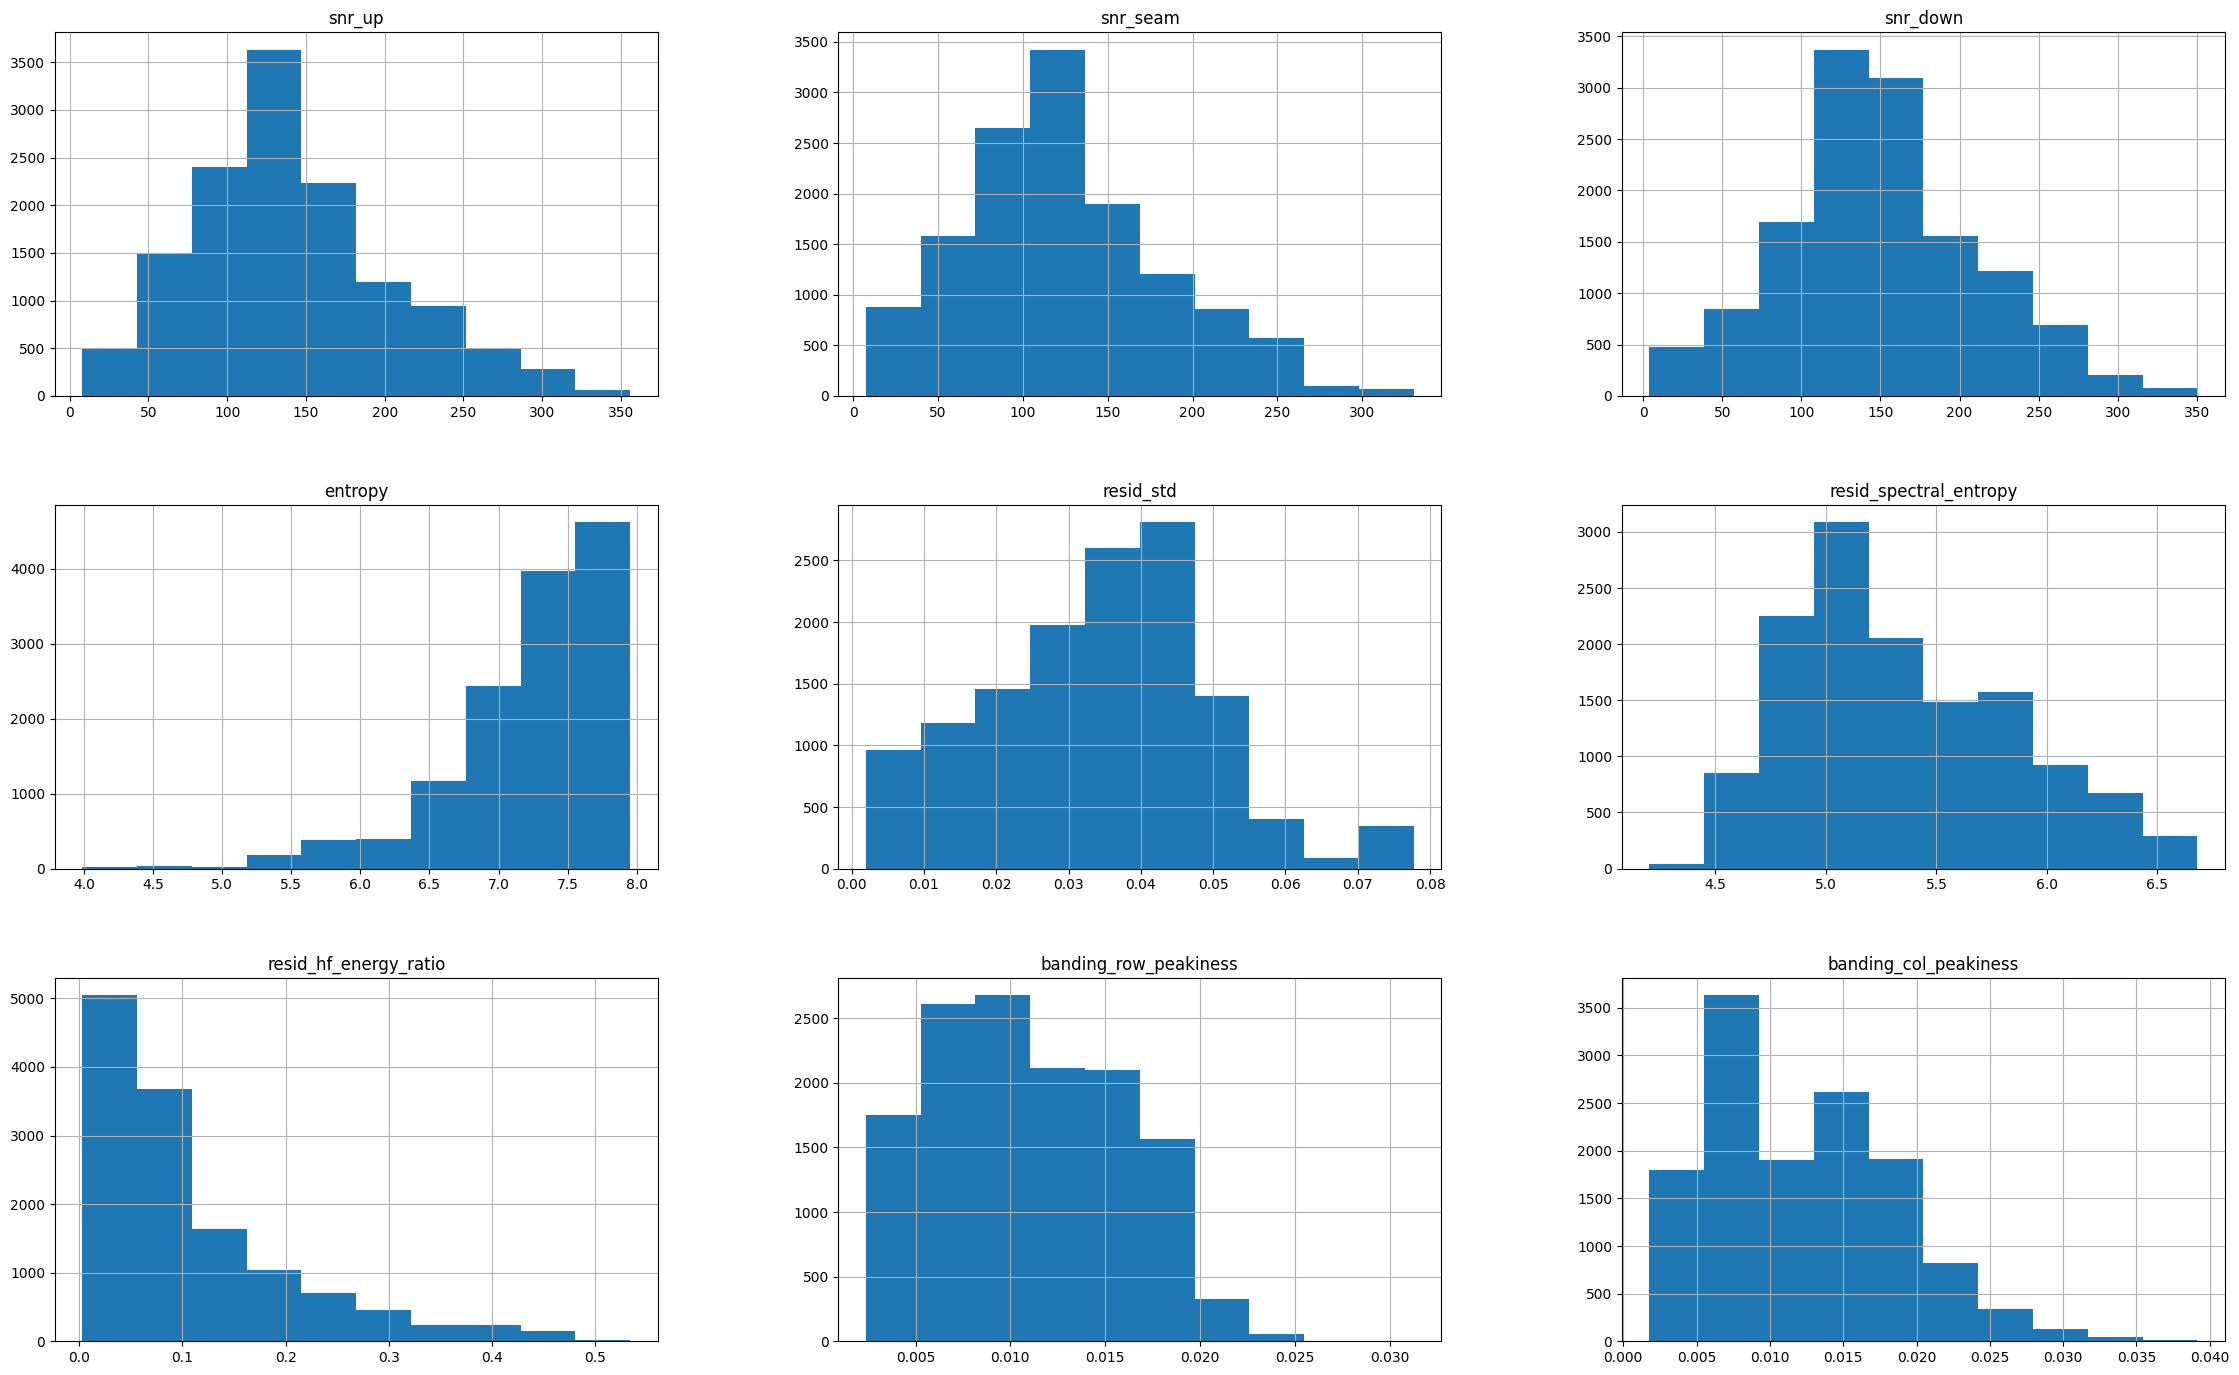

In [17]:
X1.hist(figsize=(28,17))

In [18]:
# -----------------------------
# 3) REDUNDANCY FILTER (CORRELATION)
# -----------------------------
def drop_correlated_features(X, threshold=0.95):
    corr = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return X.drop(columns=to_drop), to_drop

frame_X2, dropped_corr = drop_correlated_features(X1, threshold=0.95)
print(f"After corr filter: {frame_X2.shape[1]} (dropped {len(dropped_corr)})")

After corr filter: 9 (dropped 0)


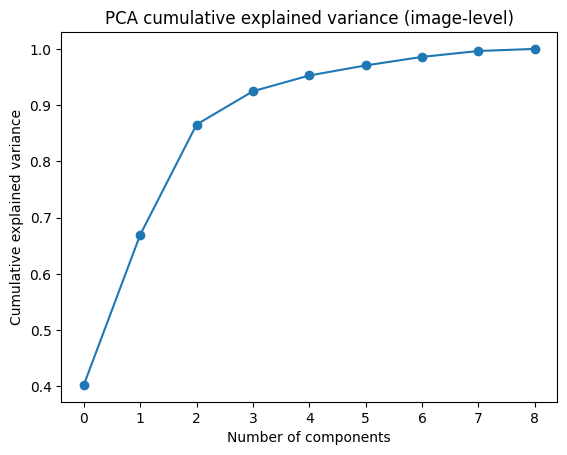

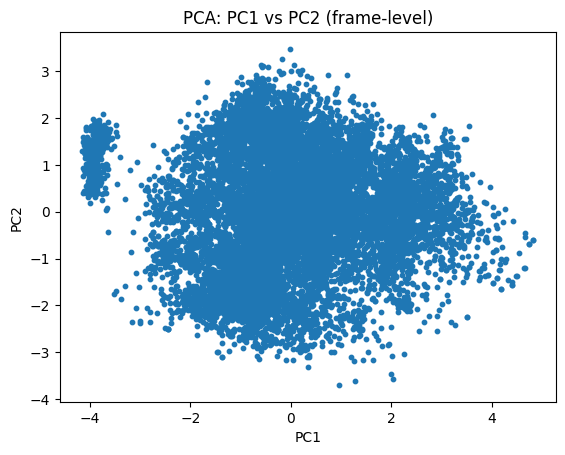

Top absolute loadings for PC1:


,std,pc1,mean
snr_down,60.68,0.25,149.44
snr_up,63.08,0.23,140.84
snr_seam,59.12,0.21,124.29
resid_hf_energy_ratio,0.10,0.17,0.11
resid_spectral_entropy,0.50,0.06,5.34
banding_col_peakiness,0.01,0.05,0.01
banding_row_peakiness,0.00,0.03,0.01
resid_std,0.02,0.01,0.03
entropy,0.56,0.00,7.22


In [19]:
# -----------------------------
# 4) PREPROCESS + PCA
# -----------------------------
preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("var", VarianceThreshold(threshold=0.0)),  # remove constants after impute
])

X_proc = preprocess.fit_transform(frame_X2)

pca = PCA(n_components=min(50, X_proc.shape[1]), random_state=0)
Z = pca.fit_transform(X_proc)

# Scree plot
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance (image-level)")
plt.show()

# PC scatter
plt.figure()
plt.scatter(Z[:, 0], Z[:, 1], s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: PC1 vs PC2 (frame-level)")
plt.show()

# Top PCA loadings (interpretability)
feature_names_after = frame_X2.columns[preprocess.named_steps["var"].get_support(indices=True)]
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names_after,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

print("Top absolute loadings for PC1:")
explained_std = loadings["PC1"].abs().sort_values(ascending=False).head(15)
tmp_df = frame_X2[explained_std.index].std()
mean_vals = frame_X2[explained_std.index].abs().mean()
pd.DataFrame([tmp_df, explained_std **2, mean_vals], index=['std', 'pc1', 'mean']).T

In [20]:
print("Top absolute loadings for PC2:")
explained_std = loadings["PC2"].abs().sort_values(ascending=False).head(15)
tmp_df = frame_X2[explained_std.index].std()
mean_vals = frame_X2[explained_std.index].abs().mean()
pd.DataFrame([tmp_df, explained_std, mean_vals], index=['std', 'pc2', 'mean']).T

Top absolute loadings for PC2:


,std,pc2,mean
banding_col_peakiness,0.01,0.40,0.01
entropy,0.56,0.40,7.22
resid_spectral_entropy,0.50,0.40,5.34
banding_row_peakiness,0.00,0.35,0.01
resid_hf_energy_ratio,0.10,0.33,0.11
resid_std,0.02,0.33,0.03
snr_down,60.68,0.27,149.44
snr_seam,59.12,0.26,124.29
snr_up,63.08,0.20,140.84


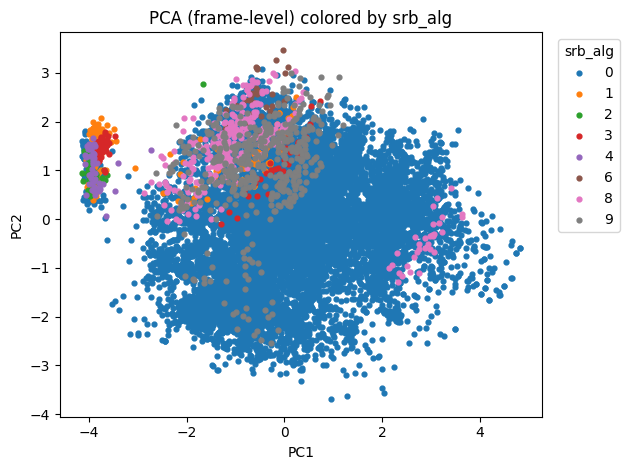

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- after you compute Z from PCA ---
# Z shape: (n_images, n_components)
pca_df = pd.DataFrame(Z[:, :2], index=frame_X2.index, columns=["PC1", "PC2"])

# Attach srb_alg (make sure it's aligned to image_id)
# If srb_alg is in df at frame-level, take per-image first (mode is typical for labels)
srb_per_image = (
    df[[IMAGE_COL, "srb_alg"]]
    .dropna()["srb_alg"]
)

pca_df["srb_alg"] = srb_per_image.reindex(pca_df.index)

# ---- Plot: categorical vs numeric ----
plt.figure()


# categorical: one color per category + legend
for val, g in pca_df.groupby("srb_alg"):
    plt.scatter(g["PC1"], g["PC2"], s=12, label=str(val))
plt.legend(title="srb_alg", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (frame-level) colored by srb_alg")
plt.tight_layout()
plt.show()

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
def plot_3d_features(feat_df, target_col):
    cols = feat_df.columns[:3]

    fig = go.Figure()

    # Add a trace for each srb_alg category
    for val, g in feat_df.groupby(target_col):
        
        hovertemplate = (
            f'<b>%{{text}}</b><br>'
            f'{cols[0]}: %{{x:.2f}}<br>'
            f'{cols[1]}: %{{y:.2f}}<br>'
            f'{cols[2]}: %{{z:.2f}}'
            '<extra></extra>'
        )
        
        fig.add_trace(go.Scatter3d(
            x=g[cols[0]],
            y=g[cols[1]],
            z=g[cols[2]],
            mode='markers',
            marker=dict(
                size=5,
                opacity=0.8
            ),
            name=str(val),
            text=g.index,
            hovertemplate= hovertemplate
        ))

    # Update layout
    fig.update_layout(
        title="3D PCA (frame-level) colored by srb_alg",
        scene=dict(
            xaxis_title=cols[0],
            yaxis_title=cols[1],
            zaxis_title=cols[2]
        ),
        legend_title="srb_alg",
        width=800,
        height=600
    )

    # Show the plot
    fig.show()

In [23]:
nmf = NMF(n_components=3)
nmf_df = pd.DataFrame(nmf.fit_transform(X = frame_X2), columns=['MNF1', 'NMF2', 'NMF3'])
nmf_df['target'] = data[COLOR_COL]

In [24]:
plot_3d_features(nmf_df, 'target')

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# --- after you compute Z from PCA ---
# Z shape: (n_images, n_components)

# Create DataFrame with first 3 components for 3D plot
pca_df = pd.DataFrame(Z[:, :3], index=frame_X2.index, columns=["PC1", "PC2", "PC3"])

# Attach srb_alg (make sure it's aligned to image_id)
# If srb_alg is in df at frame-level, take per-image first (mode is typical for labels)
srb_per_image = (
    df[[IMAGE_COL, "srb_alg"]]
    .dropna()["srb_alg"]
)
pca_df["srb_alg"] = srb_per_image.reindex(pca_df.index)

plot_3d_features(pca_df, 'srb_alg')

In [29]:
import umap
def calc_umap():
  um = umap.UMAP(n_neighbors=200, min_dist=0.05, random_state=0, n_components=3)
  U = um.fit_transform(X_proc)
  img_meta = df[COLOR_COL]
  plt.figure()
  meta = img_meta.reindex(frame_X2.index)
  umap_df = pd.DataFrame({"U1": U[:, 0], "U2": U[:, 1], "U3": U[:, 2], COLOR_COL: meta.values}, index=frame_X2.index)
  return umap_df

In [28]:
umap3d = calc_umap()

/home/akirilin/welding/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



<Figure size 640x480 with 0 Axes>

In [30]:
plot_3d_features(umap3d, 'srb_alg')

# Image level

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [109]:
# -----------------------------
# CONFIG (edit these)
# -----------------------------
IMAGE_COL = "filepath"
FRAME_COL = "frame_id"          # optional; not required
COLOR_COL = "srb_alg"           # optional; set None if you don't have it

# Filtering thresholds
MAX_MISSING_FRAC = 0.40         # drop features missing > 40%
STABILITY_THRESHOLD = 0.50      # drop unstable features: between/within ratio <= threshold
CORR_THRESHOLD = 0.90           # drop one of highly correlated pair
EPS = 1e-12

# PCA / clustering config
PCA_MAX_COMPONENTS = 50
CLUSTER_PCA_DIMS = 10           # cluster in first N PCA dims

In [110]:
data.columns

Index(['filepath', 'diameter', 'snr_up', 'snr_seam', 'snr_down', 'entropy',
       'resid_std', 'resid_mad', 'flat_resid_std', 'flat_resid_mad',
       'flat_frac', 'peak_counts_est', 'log10_peak_counts_est',
       'read_sigma_est', 'pg_r2', 'pg_intercept_b', 'pg_slope_a',
       'pg_bins_used', 'resid_spectral_entropy', 'resid_hf_energy_ratio',
       'resid_spectral_slope', 'banding_row_peakiness',
       'banding_col_peakiness', 'srb_alg', 'angle', 'dent_n', 'etal_type',
       'frame_id'],
      dtype='object')

In [111]:
# -----------------------------
# Helpers
# -----------------------------
def get_numeric_feature_cols(df, non_feature_cols):
    cols = []
    for c in df.columns:
        if c in non_feature_cols:
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            cols.append(c)
    return cols

def drop_correlated_features(X: pd.DataFrame, threshold: float = 0.95):
    corr = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if (upper[col] > threshold).any()]
    return X.drop(columns=to_drop), to_drop

def mode_or_first(s: pd.Series):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    m = s.mode()
    return m.iloc[0] if len(m) else s.iloc[0]

def eval_clusters(X_embed, labels, name):
    # handle noise label -1 (DBSCAN)
    unique = set(labels)
    if len(unique) <= 1:
        return None

    valid = labels != -1
    if valid.sum() < 3 or len(set(labels[valid])) <= 1:
        sil = np.nan
        dbi = np.nan
    else:
        sil = silhouette_score(X_embed[valid], labels[valid])
        dbi = davies_bouldin_score(X_embed[valid], labels[valid])

    sizes = pd.Series(labels).value_counts().to_dict()
    n_clusters = len(unique) - (1 if -1 in unique else 0)
    return {"method": name, "n_clusters": n_clusters, "silhouette": sil, "davies_bouldin": dbi, "sizes": sizes}

In [112]:
# -----------------------------
# 1) Build frame-level feature matrix
# -----------------------------
df = data.copy()
#df = df[df['srb_alg']>0]

if IMAGE_COL not in df.columns:
    raise ValueError(f"Missing IMAGE_COL='{IMAGE_COL}' in df.")

feature_cols = get_numeric_feature_cols(df, non_feature_cols=NON_FEATURE_COLS)
if len(feature_cols) == 0:
    raise ValueError("No numeric feature columns found. Check NON_FEATURE_COLS and dtypes.")

X_frame = df[feature_cols].replace([np.inf, -np.inf], np.nan)

# Missingness filter (frame-level)
missing_frac = X_frame.isna().mean().sort_values(ascending=False)
keep_cols = missing_frac[missing_frac <= MAX_MISSING_FRAC].index.tolist()
X_frame = X_frame[keep_cols]
print(f"[Frame-level] Features kept after missingness<= {MAX_MISSING_FRAC:.2f}: {X_frame.shape[1]}")

[Frame-level] Features kept after missingness<= 0.40: 9


In [113]:
# -----------------------------
# 2) Aggregate to image-level features
# -----------------------------
# Choose aggregation(s).
img_mean = df[[IMAGE_COL] + keep_cols].groupby(IMAGE_COL).mean(numeric_only=True)
img_median = df[[IMAGE_COL] + keep_cols].groupby(IMAGE_COL).median(numeric_only=True)
img_std = df[[IMAGE_COL] + keep_cols].groupby(IMAGE_COL).std(numeric_only=True)

# Build an image-level feature table
img_X = pd.concat(
    [
        img_mean.add_prefix("mean__"),
        img_median.add_prefix("median__"),
        img_std.add_prefix("std__"),
    ],
    axis=1,
)

print(f"[Image-level] Initial aggregated feature count: {img_X.shape[1]}")
print(f"[Image-level] Number of images: {img_X.shape[0]}")

# Also create image-level label/metadata (for coloring), if exists
img_meta = None
if COLOR_COL in df.columns:
    img_meta = df[[IMAGE_COL, COLOR_COL]].groupby(IMAGE_COL)[COLOR_COL].apply(mode_or_first)
    # Align to img_X index
    img_meta = img_meta.reindex(img_X.index)

[Image-level] Initial aggregated feature count: 27
[Image-level] Number of images: 708


In [114]:
# -----------------------------
# 3) Filter unstable features using between/within ratio
#    between = var of per-image mean (on ORIGINAL feature, not the derived prefixes)
#    within  = mean within-image var across frames
#    We'll compute stability on the base features, then keep corresponding derived features.
# -----------------------------
# base stability (on original kept_cols)
base_mean = df[[IMAGE_COL] + keep_cols].groupby(IMAGE_COL).mean(numeric_only=True)
base_var = df[[IMAGE_COL] + keep_cols].groupby(IMAGE_COL).var(numeric_only=True)

var_between = base_mean.var(axis=0)              # across images
var_within = base_var.mean(axis=0)               # average within-image
stability_score = (var_between / (var_within + EPS)).sort_values(ascending=False)

stable_base = stability_score[stability_score > STABILITY_THRESHOLD].index.tolist()
print(f"[Stability] Base features kept (score>{STABILITY_THRESHOLD}): {len(stable_base)} / {len(keep_cols)}")

# keep derived columns corresponding to stable base features
stable_prefixes = ["mean__", "median__", "std__"]
stable_derived_cols = []
for f in stable_base:
    for pref in stable_prefixes:
        col = pref + f
        if col in img_X.columns:
            stable_derived_cols.append(col)

img_X = img_X[stable_derived_cols]
print(f"[Image-level] Features after stability filter (derived): {img_X.shape[1]}")

[Stability] Base features kept (score>0.5): 9 / 9
[Image-level] Features after stability filter (derived): 27


In [115]:
# -----------------------------
# 4) Preprocess (impute/scale) + remove constants, then correlation filter
# -----------------------------
preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("var", VarianceThreshold(threshold=0.0)),
])

X_proc = preprocess.fit_transform(img_X)

# get names after VarianceThreshold
support_idx = preprocess.named_steps["var"].get_support(indices=True)
img_feature_names_after_var = img_X.columns[support_idx]

# We'll do it on the imputed (but unscaled) data to be safe.
imputed = SimpleImputer(strategy="median").fit_transform(img_X)
imputed_df = pd.DataFrame(imputed, index=img_X.index, columns=img_X.columns)

imputed_df2, dropped_corr = drop_correlated_features(imputed_df, threshold=CORR_THRESHOLD)
print(f"[Correlation] Dropped {len(dropped_corr)} features with |corr|>{CORR_THRESHOLD}. Kept: {imputed_df2.shape[1]}")

# Re-fit preprocess on de-correlated features
img_X2 = imputed_df2  # already imputed, but we keep pipeline anyway for consistency
preprocess2 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # harmless; no NaNs now
    ("scaler", RobustScaler()),
    ("var", VarianceThreshold(threshold=0.0)),
])
X_proc2 = preprocess2.fit_transform(img_X2)
final_support_idx = preprocess2.named_steps["var"].get_support(indices=True)
final_feature_names = img_X2.columns[final_support_idx]

print(f"[Final] Image-level features going into PCA: {X_proc2.shape[1]}")

[Correlation] Dropped 11 features with |corr|>0.9. Kept: 16
[Final] Image-level features going into PCA: 16


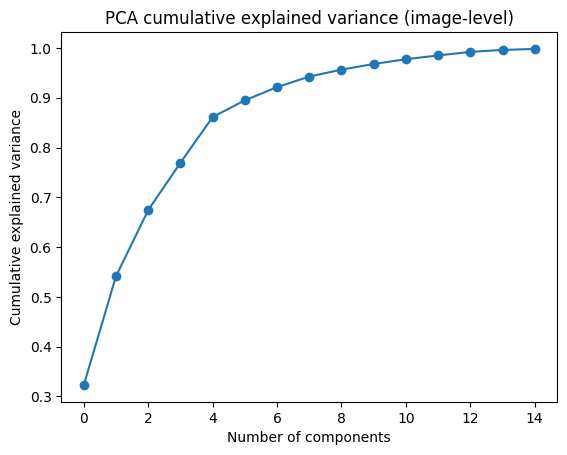

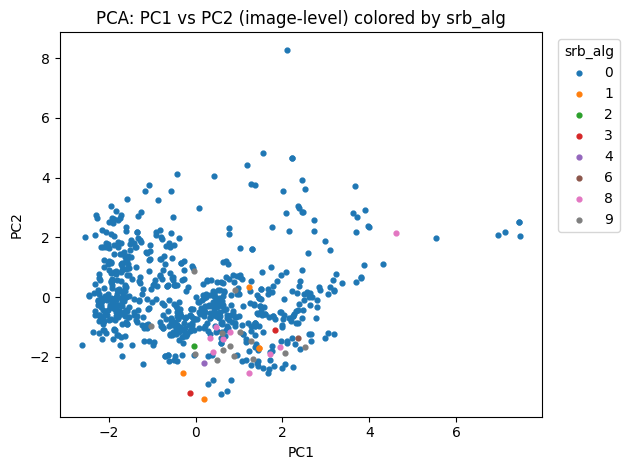


Top absolute loadings for PC1:
std__entropy                   0.51
mean__entropy                  0.34
std__banding_row_peakiness     0.29
mean__banding_row_peakiness    0.27
mean__banding_col_peakiness    0.26
mean__snr_up                   0.25
std__banding_col_peakiness     0.25
mean__resid_spectral_entropy   0.24
mean__resid_std                0.24
mean__resid_hf_energy_ratio    0.20
std__resid_std                 0.18
mean__snr_down                 0.17
std__snr_down                  0.16
std__snr_up                    0.15
std__resid_hf_energy_ratio     0.08
Name: PC1, dtype: float64


In [116]:
# -----------------------------
# 5) PCA + plots + loadings
# -----------------------------
n_comp = int(min(PCA_MAX_COMPONENTS, X_proc2.shape[1]))
pca = PCA(n_components=15, random_state=0)
Z = pca.fit_transform(X_proc2)

# Scree plot
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance (image-level)")
plt.show()

# PC scatter colored by COLOR_COL if available
plt.figure()
if img_meta is None:
    plt.scatter(Z[:, 0], Z[:, 1], s=12)
else:
    meta = img_meta.copy()
    # align to PCA row order
    meta = meta.reindex(img_X2.index)
    tmp = pd.DataFrame({"PC1": Z[:, 0], "PC2": Z[:, 1], COLOR_COL: meta.values}, index=img_X2.index)
    for val, g in tmp.groupby(COLOR_COL):
        plt.scatter(g["PC1"], g["PC2"], s=12, label=str(val))
    plt.legend(title=COLOR_COL, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA: PC1 vs PC2 (image-level){' colored by '+COLOR_COL if img_meta is not None else ''}")
plt.tight_layout()
plt.show()

# PCA loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=final_feature_names,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)
print("\nTop absolute loadings for PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False).head(15))

/home/akirilin/welding/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



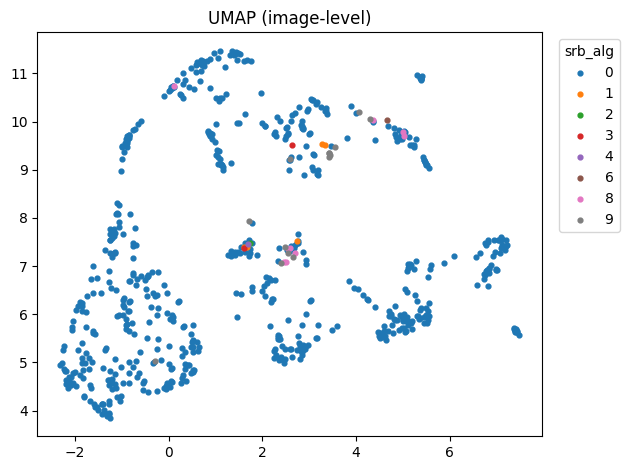

In [144]:
# -----------------------------
# 6) Optional: UMAP (if installed)
# -----------------------------
try:
    import umap

    um = umap.UMAP(n_neighbors=20, min_dist=0.05, random_state=0)
    U = um.fit_transform(X_proc2)

    plt.figure()
    if img_meta is None:
        plt.scatter(U[:, 0], U[:, 1], s=12)
    else:
        meta = img_meta.reindex(img_X2.index)
        tmp = pd.DataFrame({"U1": U[:, 0], "U2": U[:, 1], COLOR_COL: meta.values}, index=img_X2.index)
        for val, g in tmp.groupby(COLOR_COL):
            plt.scatter(g["U1"], g["U2"], s=12, label=str(val))
        plt.legend(title=COLOR_COL, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.title("UMAP (image-level)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("\nUMAP not available or failed:", repr(e))

In [145]:
detect_stat_cols =['filepath']+ list(detect_stat.columns[25:])
data_df = detect_stat[detect_stat_cols]

In [152]:
pca_df = pd.DataFrame({"PC1": Z[:, 0], "PC2": Z[:, 1], "PC3": Z[:,2], "filepath": img_X2.index})
pca_df['filepath']  = pca_df['filepath'].apply(lambda name: name[name.find('Расшифровка_v2'):])
img_stats = pca_df.reset_index(drop=True)

In [153]:
merged_df = pd.merge(img_stats, data_df)

In [154]:
merged_df

,PC1,PC2,PC3,filepath,f1_Aa,tp_Aa,fp_Aa,fn_Aa,precision_Aa,recall_Aa,...,fp_Ob4,fn_Ob4,precision_Ob4,recall_Ob4,full_file_tp,full_file_fp,full_file_fn,full_file_precision,full_file_recall,full_file_f1
0,3.82,0.63,-0.46,Расшифровка_v2/2023.08.02/567 680 (Aa10;Ва2;Fc...,0.28,4,14,7,0.22,0.36,...,0,0,0.00,0.00,4,91,18,0.04,0.18,0.07
1,3.19,0.21,-0.99,Расшифровка_v2/2023.08.02/567 710 (Aa18;Ba3;Dc...,0.00,0,0,0,0.00,0.00,...,0,0,0.00,0.00,0,0,0,0.00,0.00,0.00
2,3.24,0.78,-0.56,Расшифровка_v2/2023.08.02/567 730 (Aa12;)/567 ...,0.51,10,17,2,0.37,0.83,...,0,0,0.00,0.00,10,79,2,0.11,0.83,0.20
3,3.09,0.33,-0.51,Расшифровка_v2/2023.08.02/567 790 (Aa5;Dc3)/56...,0.00,0,0,0,0.00,0.00,...,0,0,0.00,0.00,0,0,0,0.00,0.00,0.00
4,2.78,-0.69,-0.66,Расшифровка_v2/2023.08.02/579 180 (Aa2;Ba4;Fc3...,0.00,0,2,0,0.00,0.00,...,0,0,0.00,0.00,0,3,8,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,0.60,-0.90,-0.83,Расшифровка_v2/2024.06.13/Гладков/Транскан/ОГК...,0.20,4,30,2,0.12,0.67,...,0,0,0.00,0.00,109,189,89,0.37,0.55,0.44
297,0.33,0.07,-0.94,Расшифровка_v2/2024.06.13/Гладков/Транскан/ОГК...,0.47,7,15,1,0.32,0.88,...,0,0,0.00,0.00,201,165,45,0.55,0.82,0.66
298,0.62,-0.28,-0.96,Расшифровка_v2/2024.06.13/Гладков/Транскан/ОГК...,0.43,6,15,1,0.29,0.86,...,0,0,0.00,0.00,149,199,61,0.43,0.71,0.53
299,1.02,0.68,-1.74,Расшифровка_v2/2024.06.13/Гладков/Транскан/ОГК...,0.34,6,23,0,0.21,1.00,...,0,0,0.00,0.00,166,280,45,0.37,0.79,0.51


In [155]:
import pandas as pd
import plotly.graph_objects as go

def plot_3d_features(feat_df, target_col, colorscale='Viridis'):
    """
    Plot 3D scatter of first three feature columns colored by continuous target values.
    
    Parameters:
    -----------
    feat_df : pd.DataFrame
        DataFrame containing at least 3 feature columns + target_col
    target_col : str
        Column name with continuous float values in [0, 1] range
    colorscale : str, optional
        Plotly colorscale name (e.g., 'Viridis', 'Plasma', 'RdBu', 'Inferno')
    """
    cols = feat_df.columns[:3]
    
    # Create single trace with color gradient
    hovertemplate = (
        f'<b>%{{text}}</b><br>'
        f'{cols[0]}: %{{x:.2f}}<br>'
        f'{cols[1]}: %{{y:.2f}}<br>'
        f'{cols[2]}: %{{z:.2f}}<br>'
        f'{target_col}: %{{marker.color:.3f}}'
        '<extra></extra>'
    )
    
    fig = go.Figure(data=go.Scatter3d(
        x=feat_df[cols[0]],
        y=feat_df[cols[1]],
        z=feat_df[cols[2]],
        mode='markers',
        marker=dict(
            size=5,
            opacity=0.8,
            color=feat_df[target_col],      # Continuous color mapping
            colorscale=colorscale,
            colorbar=dict(
                title=target_col,
                thickness=15,
                len=0.75,
                yanchor='middle',
                y=0.5
            ),
            cmin=0.0,  # Ensure consistent 0-1 scale
            cmax=1.0
        ),
        text=feat_df.index,
        hovertemplate=hovertemplate
    ))

    # Update layout
    fig.update_layout(
        title=f"3D Feature Plot colored by {target_col}",
        scene=dict(
            xaxis_title=cols[0],
            yaxis_title=cols[1],
            zaxis_title=cols[2]
        ),
        width=800,
        height=600,
        margin=dict(l=0, r=0, b=0, t=40)
    )

    fig.show()

In [156]:
detect_stat_cols

['filepath',
 'f1_Aa',
 'tp_Aa',
 'fp_Aa',
 'fn_Aa',
 'precision_Aa',
 'recall_Aa',
 'f1_Ak',
 'tp_Ak',
 'fp_Ak',
 'fn_Ak',
 'precision_Ak',
 'recall_Ak',
 'f1_Ba',
 'tp_Ba',
 'fp_Ba',
 'fn_Ba',
 'precision_Ba',
 'recall_Ba',
 'f1_Bd1',
 'tp_Bd1',
 'fp_Bd1',
 'fn_Bd1',
 'precision_Bd1',
 'recall_Bd1',
 'f1_Da1',
 'tp_Da1',
 'fp_Da1',
 'fn_Da1',
 'precision_Da1',
 'recall_Da1',
 'f1_Dc1',
 'tp_Dc1',
 'fp_Dc1',
 'fn_Dc1',
 'precision_Dc1',
 'recall_Dc1',
 'f1_Fa',
 'tp_Fa',
 'fp_Fa',
 'fn_Fa',
 'precision_Fa',
 'recall_Fa',
 'f1_Fc',
 'tp_Fc',
 'fp_Fc',
 'fn_Fc',
 'precision_Fc',
 'recall_Fc',
 'f1_Ob2',
 'tp_Ob2',
 'fp_Ob2',
 'fn_Ob2',
 'precision_Ob2',
 'recall_Ob2',
 'f1_Ob3',
 'tp_Ob3',
 'fp_Ob3',
 'fn_Ob3',
 'precision_Ob3',
 'recall_Ob3',
 'f1_Ob4',
 'tp_Ob4',
 'fp_Ob4',
 'fn_Ob4',
 'precision_Ob4',
 'recall_Ob4',
 'full_file_tp',
 'full_file_fp',
 'full_file_fn',
 'full_file_precision',
 'full_file_recall',
 'full_file_f1']

In [164]:
plot_3d_features(merged_df, 'full_file_fn')